# Notebook 01 — Exploratory Data Analysis

**Dataset:** UCI Online Retail II — UK-based online gift retailer, transactions from Dec 2009 to Dec 2011.

**Goal of this notebook:** Understand the shape of the data before we touch any ML. By the end, we should be able to answer:

1. How big is the data, what columns do we have, what types?
2. What's the date range, and how does revenue trend over time?
3. How dirty is it? (nulls, negative values, cancellations, weird stock codes)
4. Who are the customers? (geographic split, repeat vs. one-time)
5. What are the top products and categories?
6. What initial business questions or modeling ideas does the data suggest?

**We do NOT clean the data here.** We only observe. Cleaning is Notebook 02. The reason: if you clean while exploring, you'll forget what you removed and why. EDA's job is to inform cleaning decisions, not perform them.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,5)

## 1. Load the data

Two important things on this load:

- We parse `InvoiceDate` as a datetime up front so we can do time-based operations later.
- We keep `Invoice` and `StockCode` as **strings**, not numbers. Cancellations have invoices like `C489449` (the `C` prefix matters), and some stock codes are alphanumeric (`85048`, `79323P`). If pandas infers them as int, we lose information.

In [2]:
# Load Data
df = pd.read_csv("../data/raw/online_retail_II.csv", dtype={'Invoice': str, 'StockCode': str, 'Customer ID': str}, parse_dates=['InvoiceDate'])

# Rename 'Customer ID' to 'CustomerID' --> easier to work with
df = df.rename(columns={'Customer ID':'CustomerID'})
    
print(f'Shape {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape 1,067,371 rows x 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Time range & basic counts

First sanity check: when does the data cover, and how many unique invoices/customers/products?

In [3]:
# Time range & basic counts
print('Date range')
print(f'    From:   {df['InvoiceDate'].min()}')
print(f'    To:     {df['InvoiceDate'].max()}')
print(f'    Span:   {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days')

print('\nBasic Counts')
print(f'Invoices:   {df['Invoice'].nunique():,}')
print(f'Customers:  {df['CustomerID'].nunique():,}')
print(f'Products:   {df['StockCode'].nunique():,}')
print(f'Countries:  {df['Country'].nunique()}')

Date range
    From:   2009-12-01 07:45:00
    To:     2011-12-09 12:50:00
    Span:   738 days

Basic Counts
Invoices:   53,628
Customers:  5,942
Products:   5,305
Countries:  43


## 3. Missing values

Critical for ML: nulls in features are usually OK if we handle them; nulls in the target or in identifiers we depend on are blockers.

**What we care about:**
- `CustomerID` nulls → these rows can't be attributed to a customer, so they're useless for customer-level modeling (CLV, churn, segmentation). But they're still real revenue, so they're fine for product-level analysis.
- `Description` nulls → minor; usually paired with weird StockCodes (admin items).

In [4]:
# Check missing value
missing = df.isnull().sum()
missing_pct = ((missing / len(df) * 100)).round(2)
pd.DataFrame({'missing': missing, 'percentage': missing_pct}).sort_values('missing', ascending=False)

,missing,percentage
CustomerID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


**Observation:** ~23% of rows have null `CustomerID`. That's a lot — but expected for this dataset (guest checkouts). We'll drop these for customer-level work in Notebook 02 but keep them for product analysis.

## 4. Cancellations

In this dataset, cancellations/returns are flagged by an `Invoice` starting with `C`. They have negative quantities. We need to know how many there are because:

- For revenue analysis, cancellations should net out (a sale + a return = 0 net revenue)
- For churn modeling, a customer with many returns is a signal
- For predictive features, we may want a `return_rate` per customer

In [5]:
# Analyze cancellation 
df['is_cancellation'] = df['Invoice'].str.startswith('C')

cancel_summary = df.groupby('is_cancellation').agg(
    rows=('Invoice', 'size'),
    unique_invoices=('Invoice', 'nunique'),
    total_quantity=('Quantity', 'sum')
).rename(index={False: 'Sale', True: 'Cancellation'})

print(cancel_summary)
print(f'\nCancellation rows share: {df['is_cancellation'].mean() * 100:.2f}%')

                    rows  unique_invoices  total_quantity
is_cancellation                                          
Sale             1047877            45336        11099484
Cancellation       19494             8292         -490992

Cancellation rows share: 1.83%


## 5. Quantity & Price distributions — finding the weird stuff

We want to see the full distribution including negatives and outliers. The summary stats will probably show:
- Negative quantities (cancellations)
- Negative prices (data errors or adjustments — should be rare)
- Extreme positive outliers (bulk B2B orders or data entry errors)
- Zero prices (free samples? gifts? bad data?)

In [6]:
print('Quantity:')
print(df['Quantity'].describe())
print()
print('Price:')
print(df['Price'].describe())

Quantity:
count   1,067,371.00
mean            9.94
std           172.71
min       -80,995.00
25%             1.00
50%             3.00
75%            10.00
max        80,995.00
Name: Quantity, dtype: float64

Price:
count   1,067,371.00
mean            4.65
std           123.55
min       -53,594.36
25%             1.25
50%             2.10
75%             4.15
max        38,970.00
Name: Price, dtype: float64


In [7]:
# How many rows have suspicous value?
print("Suspicous value count:")
print(f'Quantity == 0 : {(df['Quantity'] == 0).sum():,}')
print(f'Quantity < 0 : {(df['Quantity'] < 0).sum():,} (likely cancellation)')
print(f'Quantity > 1000 : {(df['Quantity'] > 1000).sum():,} (bulk or error)') 
print(f'Price == 0 : {(df['Price'] == 0).sum():,}')
print(f'Price > 100 : {(df['Price'] > 100).sum():,}')
print(f'Price < 0 : {(df['Price'] < 0).sum():,}')

Suspicous value count:
Quantity == 0 : 0
Quantity < 0 : 22,950 (likely cancellation)
Quantity > 1000 : 352 (bulk or error)
Price == 0 : 6,202
Price > 100 : 1,946
Price < 0 : 5


In [8]:
# Look at the most extreme quantity outliers
df.nlargest(10, 'Quantity')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'CustomerID', 'Country']]

,Invoice,StockCode,Description,Quantity,Price,CustomerID,Country
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902.0,Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902.0,Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902.0,Denmark
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,0.10,13902.0,Denmark
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,13256.0,United Kingdom
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,0.10,13902.0,Denmark
192197,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,0.00,NaN,United Kingdom
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,0.25,17940.0,United Kingdom


In [9]:
# Look at the zero-price rows - why are they?
df[df['Price'] == 0]['Description'].value_counts().head(15)

Description
check                           162
?                                92
damages                          84
damaged                          81
found                            28
missing                          27
sold as set on dotcom            20
Damaged                          17
adjustment                       16
OWL DOORSTOP                     15
POLYESTER FILLER PAD 45x45cm     12
dotcom                           12
amazon                           11
POLYESTER FILLER PAD 40x40cm     10
IVORY KITCHEN SCALES             10
Name: count, dtype: int64

**Observation:** zero-price rows are likely a mix of samples, adjustments, and data errors. We'll filter most of them out in Notebook 02.

## 6. Non-product StockCodes

Some `StockCode` values aren't products — they're things like `POST` (postage), `BANK CHARGES`, `M` (manual adjustment), `DOT` (dotcom postage), `AMAZONFEE`, etc. These will pollute our product analysis and need to be excluded.

Heuristic: real product codes are mostly 5-6 digit numeric or numeric+letter. Admin codes tend to be short and all letters.

In [10]:
# Stock codes that don't start with a digit are often admin/fee items
non_numeric_codes = df[~df['StockCode'].str[0].str.isdigit()]
print('Non-numeric stock codes (top 20):')
print(non_numeric_codes['StockCode'].value_counts().head(20))

Non-numeric stock codes (top 20):
StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
gift_0001_10      16
CRUK              16
DCGS0076          15
TEST001           15
DCGS0003          14
Name: count, dtype: int64


In [11]:
# Inspect what each non-product code represents
non_product_codes = ['POST','DOT','M','C2','D','S','BANK CHARGES','ADJUST','AMAZONFEE',
                    'DCGS0058','gift_0001_20','gift_0001_30','DCGSSGIRL','DCGSSBOY','PADS',
                    'gift_0001_10','CRUK','DCGS0076','TEST001','DCGS0003']
for code in non_product_codes:
    rows = df[df['StockCode'] == code]
    if len(rows) > 0:
        sample_desc = rows['Description'].dropna().unique()[:2]
        print(f'    {code:18s} | {len(rows):>6,} rows | {sample_desc}')

    POST               |  2,122 rows | <ArrowStringArray>
['POSTAGE']
Length: 1, dtype: str
    DOT                |  1,446 rows | <ArrowStringArray>
['DOTCOM POSTAGE']
Length: 1, dtype: str
    M                  |  1,421 rows | <ArrowStringArray>
['Manual']
Length: 1, dtype: str
    C2                 |    282 rows | <ArrowStringArray>
['CARRIAGE']
Length: 1, dtype: str
    D                  |    177 rows | <ArrowStringArray>
['Discount']
Length: 1, dtype: str
    S                  |    104 rows | <ArrowStringArray>
['SAMPLES']
Length: 1, dtype: str
    BANK CHARGES       |    102 rows | <ArrowStringArray>
[' Bank Charges', 'Bank Charges']
Length: 2, dtype: str
    ADJUST             |     67 rows | <ArrowStringArray>
['Adjustment by john on 26/01/2010 16', 'Adjustment by john on 26/01/2010 17']
Length: 2, dtype: str
    AMAZONFEE          |     43 rows | <ArrowStringArray>
['AMAZON FEE']
Length: 1, dtype: str
    DCGS0058           |     31 rows | <ArrowStringArray>
['MISO PRETTY 

In [12]:
for code in ['S', 'ADJUST']:
    rows = df[df['StockCode'] == code]
    print(f"\n=== {code} ({len(rows)} rows) ===")
    print(f"Description: {rows['Description'].value_counts().head(5).to_dict()}")
    print(f"Price range: {rows['Price'].min()} to {rows['Price'].max()}")
    print(f"Quantity range: {rows['Quantity'].min()} to {rows['Quantity'].max()}")


=== S (104 rows) ===
Description: {'SAMPLES': 104}
Price range: 2.8 to 605.18
Quantity range: -1 to 1

=== ADJUST (67 rows) ===
Description: {'Adjustment by john on 26/01/2010 16': 38, 'Adjustment by john on 26/01/2010 17': 26, 'Adjustment by Peter on 24/05/2010 1': 3}
Price range: 4.57 to 5117.03
Quantity range: -1 to 1


In [13]:
# Investigate DCGS-prefixed StockCodes
dcgs = df[df['StockCode'].str.startswith('DCGS', na=False)].copy()

print(f"Total DCGS rows: {len(dcgs):,} rows")
print(f"Unique DCGS StockCodes: {dcgs['StockCode'].nunique()}")
print(f"Date range: {dcgs['InvoiceDate'].min()} to {dcgs['InvoiceDate'].max()}")
print()

# What descriptions does each DCGS code have?
print("=== DCGS StockCode Descriptions ===")
desc_by_code = (
    dcgs.groupby('StockCode')['Description']
        .agg(lambda x: x.dropna().unique().tolist() or ['<all null>'])
)
for code, desc_list in desc_by_code.items():
    n = (dcgs['StockCode'] == code).sum()
    print(f"    {code:12s} ({n:>3} rows) | {desc_list}")

Total DCGS rows: 158 rows
Unique DCGS StockCodes: 34
Date range: 2009-12-01 14:28:00 to 2011-12-01 16:22:00

=== DCGS StockCode Descriptions ===
    DCGS0003     ( 14 rows) | ['BOXED GLASS ASHTRAY', 'ebay']
    DCGS0004     (  5 rows) | ['HAYNES CAMPER SHOULDER BAG']
    DCGS0006     (  1 rows) | ['<all null>']
    DCGS0016     (  1 rows) | ['<all null>']
    DCGS0027     (  1 rows) | ['<all null>']
    DCGS0036     (  1 rows) | ['<all null>']
    DCGS0037     (  2 rows) | ['KEY-RING CORKSCREW']
    DCGS0039     (  1 rows) | ['<all null>']
    DCGS0041     (  1 rows) | ['HAYNES MINI-COOPER PLAYING CARDS']
    DCGS0044     (  1 rows) | ['HANDZ-OFF CAR FRESHENER']
    DCGS0053     (  1 rows) | ['<all null>']
    DCGS0055     (  1 rows) | ['<all null>']
    DCGS0056     (  1 rows) | ['<all null>']
    DCGS0057     (  1 rows) | ['<all null>']
    DCGS0058     ( 31 rows) | ['MISO PRETTY  GUM']
    DCGS0059     (  1 rows) | ['<all null>']
    DCGS0060     (  1 rows) | ['<all null>']
    DCGS

In [14]:
# Are DCGS rows priced like real products?
print("DCGS price/quantity stats:")
print(dcgs[['Quantity','Price']].describe())
print()
print(f"Price == 0 rows: {(dcgs['Price'] == 0).sum()}")
print(f"Quantity <= 0 rows: {(dcgs['Quantity'] <= 0).sum()}")
print(f"Null Description rows: {(dcgs['Description'].isnull().sum())}")
print()

# Look at the rows that WOULD survive cleaning (positive qty, positive price, valid descriptions)
survivors = dcgs[(dcgs['Quantity'] > 0) & (dcgs['Price'] > 0) & (dcgs['Description'].notna())]
print(f"DCGS rows that would survive cleaning: {len(survivors)} of {len(dcgs)}")
print()
print("Sample survivors:")
survivors.sample(min(10, len(survivors)), random_state=42)[['StockCode','Description','Quantity','Price', 'Country']]

DCGS price/quantity stats:
       Quantity  Price
count    158.00 158.00
mean       1.39   4.45
std       14.57   5.59
min      -90.00   0.00
25%        1.00   0.81
50%        1.00   2.57
75%        2.00   3.36
max      100.00  17.35

Price == 0 rows: 33
Quantity <= 0 rows: 28
Null Description rows: 26

DCGS rows that would survive cleaning: 125 of 158

Sample survivors:


,StockCode,Description,Quantity,Price,Country
37222,DCGS0058,MISO PRETTY GUM,1,0.83,United Kingdom
171527,DCGS0058,MISO PRETTY GUM,1,0.81,United Kingdom
148841,DCGS0069,OOH LA LA DOGS COLLAR,1,16.13,United Kingdom
409703,DCGS0058,MISO PRETTY GUM,2,0.95,United Kingdom
244831,DCGSSGIRL,GIRLS PARTY BAG,3,3.36,United Kingdom
524271,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,1,16.13,United Kingdom
249937,DCGSSBOY,BOYS PARTY BAG,3,3.36,United Kingdom
1000063,DCGSSGIRL,GIRLS PARTY BAG,1,3.29,United Kingdom
550367,DCGS0003,BOXED GLASS ASHTRAY,1,2.51,United Kingdom
8373,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,1,16.48,United Kingdom


**Decision for cleaning:** drop rows where `StockCode` is in our admin list. We'll formalize this in Notebook 02.

## 7. Revenue over time

Create a `Revenue` column and look at the time trend. This is the single most important plot for a business stakeholder — and it tells us:
- Is the business growing, flat, or shrinking?
- Is there seasonality (holiday spikes)?
- Are there weekly patterns (weekday vs. weekend)?
- Any data gaps or anomalies?

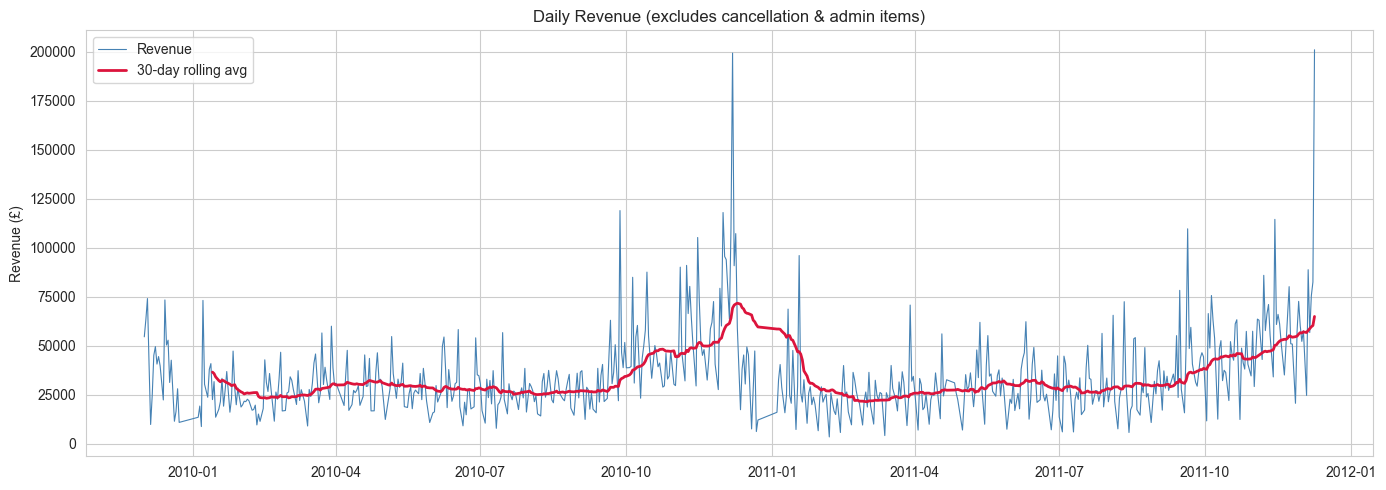

In [12]:
df['Revenue'] = df['Quantity'] * df['Price']

# For trend analysis, exclude cancellation and admin items just for this view
view = df[(~df['is_cancellation']) & (df['Quantity'] > 0) & (df['Price'] > 0)].copy()
view['Date'] = view['InvoiceDate'].dt.date

daily_revenue = view.groupby('Date')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(14,5))
daily_revenue.plot(ax=ax, color='steelblue', linewidth=0.8)
daily_revenue.rolling(30).mean().plot(ax=ax, color='crimson', linewidth=2, label='30-day rolling avg')
ax.set_title('Daily Revenue (excludes cancellation & admin items)')
ax.set_ylabel('Revenue (£)')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

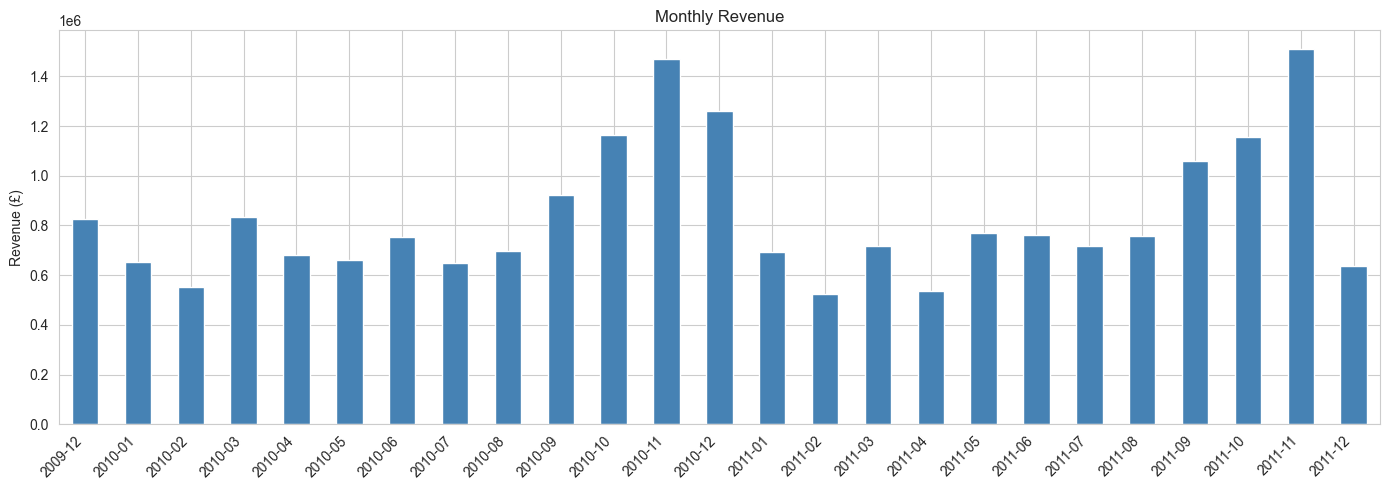

In [13]:
# Monthly revenue - easier to spot seasonality
view['YearMonth'] = view['InvoiceDate'].dt.to_period('M')
monthly_revenue = view.groupby('YearMonth')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(14,5))
monthly_revenue.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Monthly Revenue')
ax.set_ylabel('Revenue (£)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation:** classic holiday-driven retail pattern. Watch for the Nov-Dec spike both years — that's a huge promotional opportunity signal.

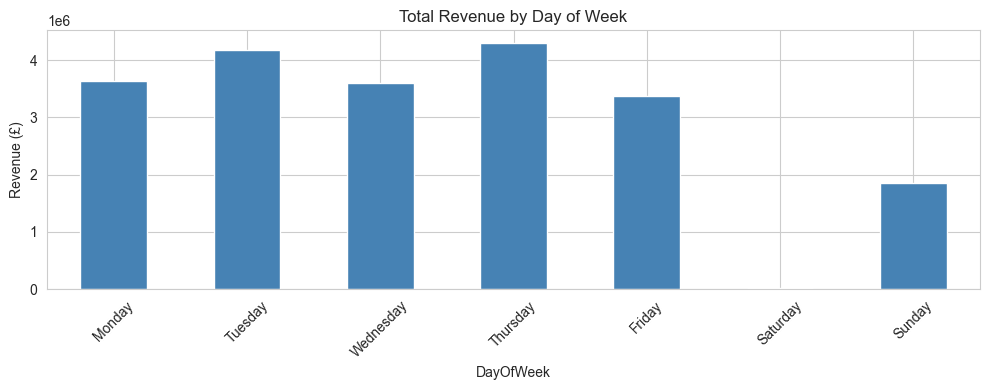

In [14]:
# Day-of-week pattern
view['DayOfWeek'] = view['InvoiceDate'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_revenue = view.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10,4))
dow_revenue.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Total Revenue by Day of Week')
ax.set_ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

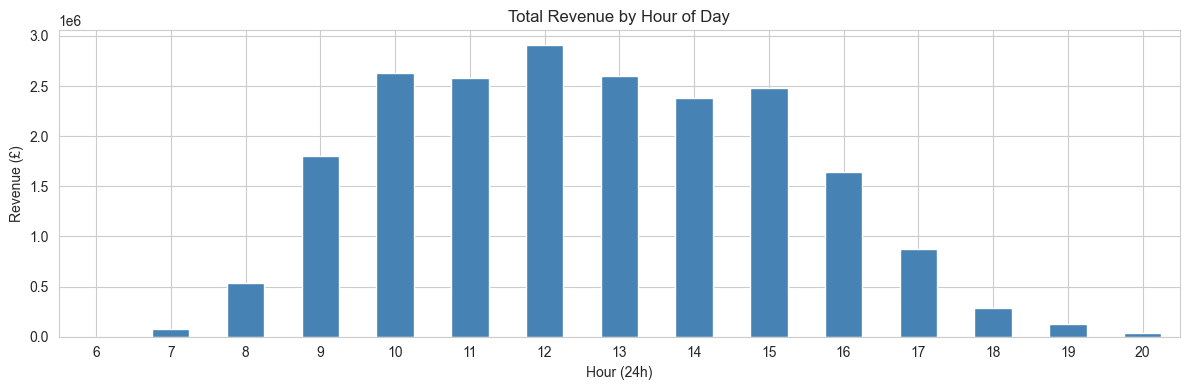

In [15]:
# Hour-of-day pattern - when do people shop?
view['Hour'] = view['InvoiceDate'].dt.hour
hour_revenue = view.groupby('Hour')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(12,4))
hour_revenue.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Total Revenue by Hour of Day')
ax.set_ylabel('Revenue (£)')
ax.set_xlabel('Hour (24h)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** no Saturday data (closed?) and shopping concentrates in business hours. Both are clues about the business model — this is likely B2B (wholesale to gift shops) more than B2C. Worth confirming with average order value below.

## 8. Geographic distribution

UK dominates this dataset, but the international segment matters for strategy (different shipping, different segments).

In [16]:
country_stats = view.groupby('Country').agg(
    revenue=('Revenue','sum'),
    orders=('Invoice','nunique'),
    customers=('CustomerID','nunique'),
).sort_values('revenue', ascending=False)

country_stats['revenue_share_pct'] = (country_stats['revenue'] / country_stats['revenue'].sum() * 100).round(2)
country_stats.head(15)

,revenue,orders,customers,revenue_share_pct
Country,,,,
United Kingdom,"17,870,977.78",36535,5350,85.21
EIRE,"664,431.78",626,5,3.17
Netherlands,"554,232.34",228,22,2.64
Germany,"431,262.46",789,107,2.06
France,"356,944.60",622,95,1.70
Australia,"169,968.11",95,15,0.81
Spain,"109,178.53",154,41,0.52
Switzerland,"101,011.29",93,22,0.48
Sweden,"91,903.72",105,19,0.44


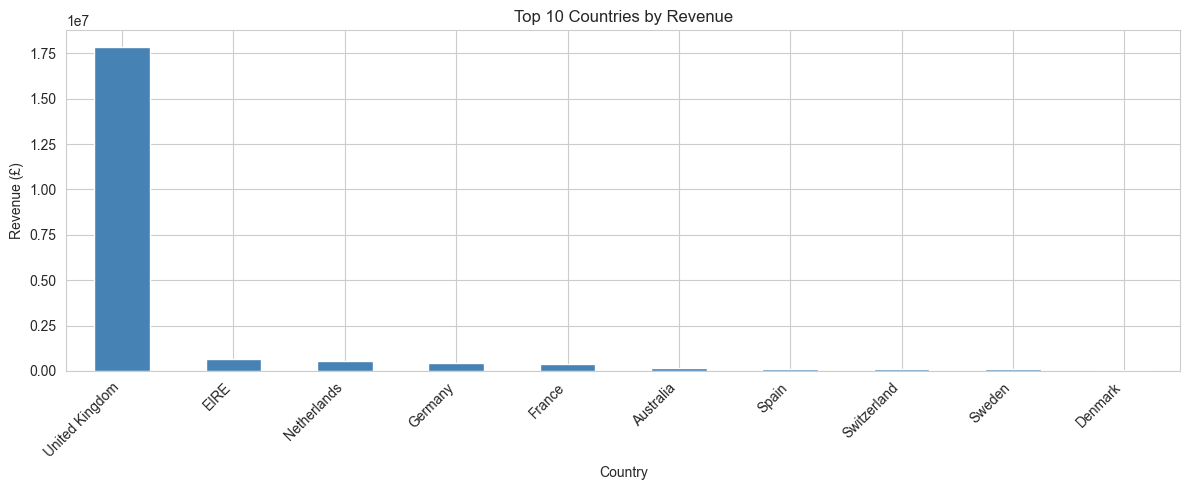

In [17]:
fig, ax = plt.subplots(figsize=(12,5))
country_stats.head(10)['revenue'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 Countries by Revenue')
ax.set_ylabel('Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Customer concentration — Pareto check

In retail, revenue almost always follows the 80/20 rule (or worse). Knowing this shapes our strategy: if the top 20% of customers drive 80% of revenue, retention matters more than acquisition.

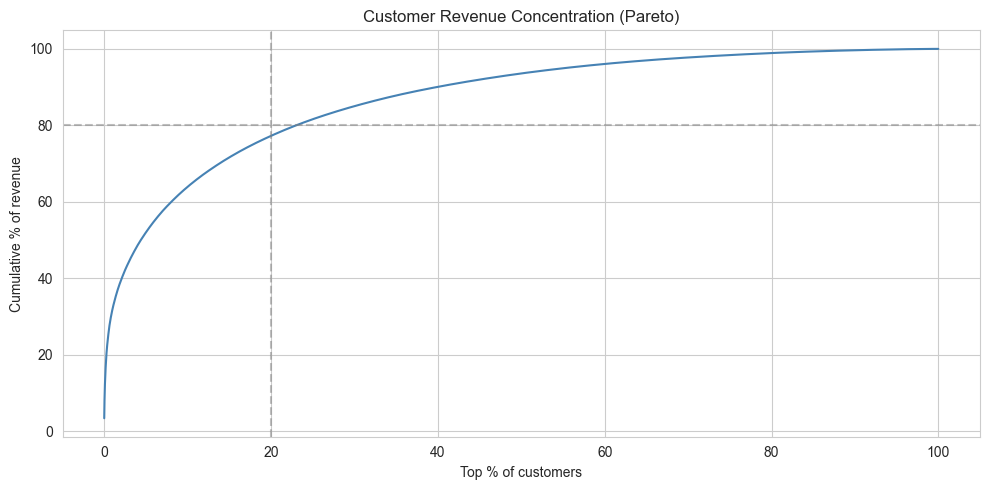


Top 20% of customers (1,175 customers) drive 77.2% of revenue.


In [18]:
# Customer revenue (only customer with IDs)
customer_view = view.dropna(subset=['CustomerID'])
customer_revenue = customer_view.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

# Cumulative revenue share
cumulative = customer_revenue.cumsum() / customer_revenue.sum()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(len(cumulative)) / len(cumulative) * 100, cumulative.values * 100, color='steelblue')
ax.axhline(80, color='gray', linestyle='--', alpha=0.5)
ax.axvline(20, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Top % of customers')
ax.set_ylabel('Cumulative % of revenue')
ax.set_title('Customer Revenue Concentration (Pareto)')
plt.tight_layout()
plt.show()

# What % of revenue comes from top 20% of customers?
top_20_pct_count = int(len(customer_revenue) * 0.2)
top_20_revenue_share = customer_revenue.head(top_20_pct_count).sum() / customer_revenue.sum() * 100
print(f'\nTop 20% of customers ({top_20_pct_count:,} customers) drive {top_20_revenue_share:.1f}% of revenue.')

In [19]:
# How many orders per customer? (Frequency distribution)
orders_per_customer = customer_view.groupby('CustomerID')['Invoice'].nunique()
print('Order per customer:')
print(orders_per_customer.describe())
print()
print('Customer breakdown:')
print(f'    One-time customers:     {(orders_per_customer == 1).sum():,} ({(orders_per_customer == 1).mean() * 100:.1f}%)')
print(f'    Repeat (2-5 orders):    {((orders_per_customer >= 2) & (orders_per_customer <= 5)).sum():,}')
print(f'    Loyal (6-20 orders):    {((orders_per_customer >= 6) & (orders_per_customer <= 20)).sum():,}')
print(f'    VIP (21+ orders):       {(orders_per_customer >= 21).sum():,}')

Order per customer:
count   5,878.00
mean        6.29
std        13.01
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       398.00
Name: Invoice, dtype: float64

Customer breakdown:
    One-time customers:     1,623 (27.6%)
    Repeat (2-5 orders):    2,454
    Loyal (6-20 orders):    1,504
    VIP (21+ orders):       297


## 10. Average Order Value (AOV) — B2C or B2B?

Big AOVs and large quantities per order suggest wholesale/B2B. Small AOVs suggest retail/B2C. This affects our entire strategy.

In [20]:
order_value = view.groupby('Invoice').agg(
    order_value=('Revenue', 'sum'),
    items_in_order=('StockCode', 'count'),
    total_quantity=('Quantity', 'sum')
)

print('Order-level stats:')
print(order_value.describe())

Order-level stats:
       order_value  items_in_order  total_quantity
count    40,077.00       40,077.00       40,077.00
mean        523.31           25.99          284.96
std       1,517.37           46.11        1,200.31
min           0.19            1.00            1.00
25%         151.97            6.00           66.00
50%         304.31           16.00          149.00
75%         504.90           29.00          292.00
max     168,469.60        1,350.00       87,167.00


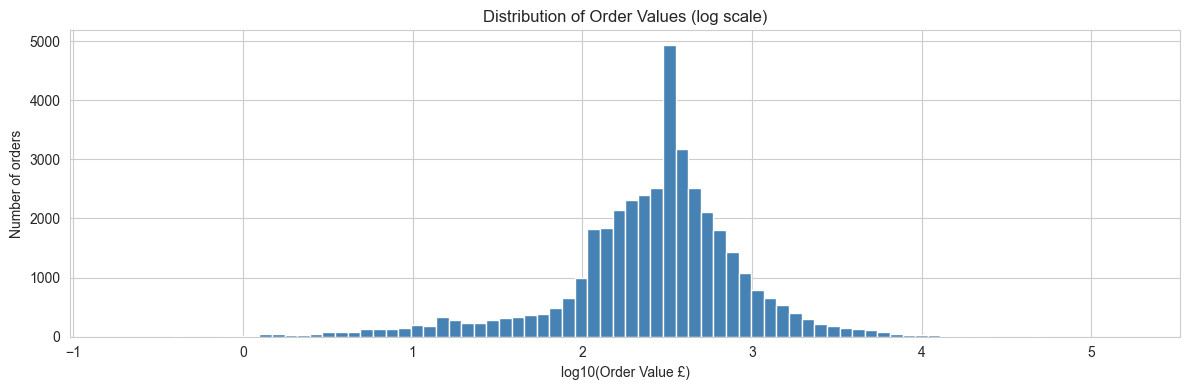

In [21]:
# AOV distribution (log scale because of skew)
fig, ax = plt.subplots(figsize=(12,4))
ax.hist(np.log10(order_value['order_value'].clip(lower=0.01)), bins=80, color='steelblue', edgecolor='white')
ax.set_xlabel('log10(Order Value £)')
ax.set_ylabel('Number of orders')
ax.set_title('Distribution of Order Values (log scale)')
plt.tight_layout()
plt.show()

**Observation:** the median order is ~£300+ with many items per invoice → this is wholesale/B2B (gift shops buying inventory), not direct-to-consumer. That changes our segmentation and promotion logic — we're targeting buyers who place re-stock orders, not individual shoppers.

## 11. Top products

Two different views: most-sold (by units) and most-profitable (by revenue). These are often different — cheap items might top the units list but barely register on revenue.

In [22]:
# Top 15 by units sold
top_by_units = view.groupby(['StockCode','Description']).agg(
    units_sold=('Quantity', 'sum'),
    revenue=('Revenue','sum')
).sort_values('units_sold', ascending=False).head(15)
print('Top 15 products by units sold')
top_by_units

Top 15 products by units sold


,,units_sold,revenue
StockCode,Description,,
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,110138,"25,259.90"
85123A,WHITE HANGING HEART T-LIGHT HOLDER,96086,"262,931.16"
84879,ASSORTED COLOUR BIRD ORNAMENT,81809,"132,187.92"
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60"
85099B,JUMBO BAG RED RETROSPOT,78860,"148,823.92"
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92"
17003,BROCADE RING PURSE,71430,"14,959.19"
21977,PACK OF 60 PINK PAISLEY CAKE CASES,56794,"28,490.98"
84991,60 TEATIME FAIRY CAKE CASES,54716,"27,404.22"


In [23]:
# Top 15 by revenue
top_by_revenue = view.groupby(['StockCode','Description']).agg(
    units_sold=('Quantity','sum'),
    revenue=('Revenue','sum')
).sort_values('revenue', ascending=False)
print('Top 15 products by revenue')
top_by_revenue

Top 15 products by revenue


,,units_sold,revenue
StockCode,Description,,
22423,REGENCY CAKESTAND 3 TIER,27577,"344,563.25"
M,Manual,10050,"340,716.28"
DOT,DOTCOM POSTAGE,1436,"322,657.48"
85123A,WHITE HANGING HEART T-LIGHT HOLDER,96086,"262,931.16"
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60"
...,...,...,...
84206B,CAT W SUNGLASSES BLANK CARD,4,0.76
23366,SET 12 COLOURING PENCILS DOILEY,1,0.65
35930,PINK HEART CHRISTMAS DECORATION,1,0.38


## 12. Customer cohort sneak-peek

A quick look at customer acquisition over time. We're not doing full cohort analysis yet (that's Notebook 04), but seeing when customers first appeared tells us about growth and informs CLV modeling.

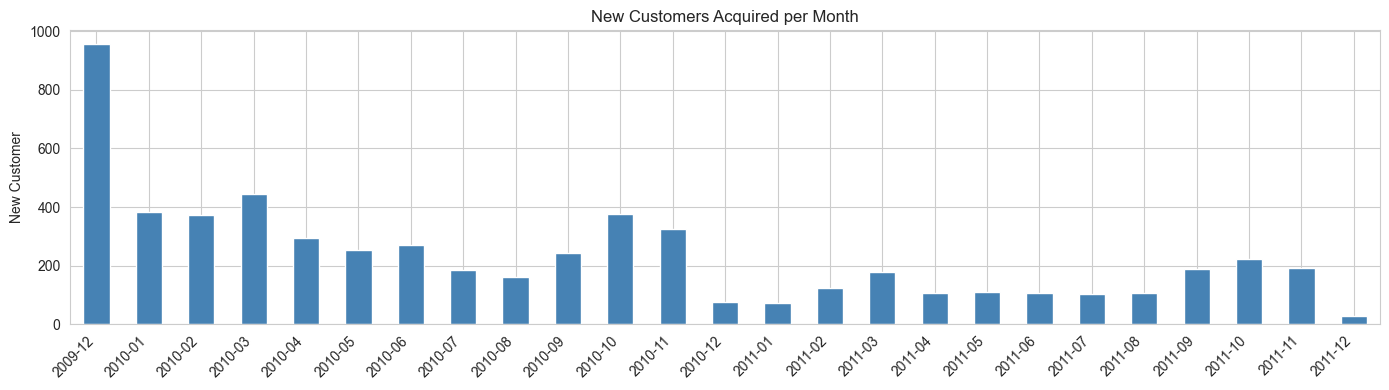

In [24]:
first_purchase = customer_view.groupby('CustomerID')['InvoiceDate'].min().dt.to_period('M')
new_customers_per_month = first_purchase.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14,4))
new_customers_per_month.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('New Customers Acquired per Month')
ax.set_ylabel('New Customer')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 13. EDA Summary & Decisions

What we learned (fill these in with your actual numbers after running):

### Data quality issues to handle in Notebook 02
- [ ] ~23% of rows have null `CustomerID` → drop for customer-level work, keep for product-level
- [ ] ~1.8% are cancellations (Invoice starts with `C`) → split into separate signal
- [ ] Negative quantities and prices exist → filter out for sales analysis
- [ ] Zero-price rows exist → investigate and filter
- [ ] Non-product StockCodes (`POST`, `M`, `BANK CHARGES`, etc.) → drop
- [ ] Extreme outliers in Quantity (80k+) → investigate, likely bulk orders or errors

### Business observations
- This is a **B2B wholesale** business, not B2C → AOV is high, customers are gift shops buying inventory
- Heavy **Nov-Dec seasonality** → promotion strategy must account for holiday cycle
- **UK is 92% of revenue** → segmenting by domestic vs. international is a natural cut
- **Customer concentration is severe** → top 20% likely drives most revenue → retention focus
- **No Saturday activity** → operational schedule worth confirming with the business

### Modeling ideas for later notebooks
1. **RFM segmentation** → natural starting point given clear customer revenue concentration
2. **CLV regression** → predict 90-day revenue per customer (B2B = predictable re-orders)
3. **Churn classification** → predict whether a customer will re-order; high-value churners are the priority
4. **Market basket** → product co-purchase patterns for cross-sell
5. **Time-series demand forecasting** (stretch) → predict inventory needs leading into Q4 spike

### Strategy hypotheses to test
- **H1:** A small set of "hero products" drives most revenue → bundling around them increases AOV
- **H2:** International customers have different buying patterns → tailored offers per region
- **H3:** Customers with declining order frequency in the last 60 days are about to churn → win-back campaign before they lapse
- **H4:** Repeat customers gradually expand their product mix → personalized recommendations accelerate this

---

**Next:** Notebook 02 — apply the cleaning decisions above and save a clean parquet file for downstream notebooks.